In [1]:
# Install all required libraries
!pip install librosa sentence-transformers umap-learn scikit-learn torch -q

In [2]:
import pandas as pd
import os

base = "/kaggle/input/datasets/organizations/mozillaorg/common-voice"

df = pd.read_csv(f"{base}/cv-valid-train.csv")

# Keep only filename and transcript text
df = df[["filename", "text"]].dropna()
df["filename"] = df["filename"].astype(str)
df["text"] = df["text"].astype(str)

# Build full audio file path
audio_dir = os.path.join(base, "cv-valid-train")
df["audio_path"] = df["filename"].apply(lambda x: os.path.join(audio_dir, x))

# Remove rows where audio file doesn't exist on disk
df = df[df["audio_path"].apply(os.path.exists)].reset_index(drop=True)

#Sample max 10k to keep runtime manageable on Kaggle
if len(df) > 5000:
    df = df.sample(n=12000, random_state=42).reset_index(drop=True)

print(df.head())
print("Total samples:", len(df))

                           filename  \
0  cv-valid-train/sample-182715.mp3   
1  cv-valid-train/sample-114956.mp3   
2  cv-valid-train/sample-139880.mp3   
3  cv-valid-train/sample-034538.mp3   
4  cv-valid-train/sample-142907.mp3   

                                                text  \
0  the fine manufacturing company was a bookkeepe...   
1  the mixture took on a reddish color almost the...   
2                                enough said the boy   
3  then he sat in the sunfilled doorway smoking t...   
4  i've just guaranteed the bank sufficient funds...   

                                          audio_path  
0  /kaggle/input/datasets/organizations/mozillaor...  
1  /kaggle/input/datasets/organizations/mozillaor...  
2  /kaggle/input/datasets/organizations/mozillaor...  
3  /kaggle/input/datasets/organizations/mozillaor...  
4  /kaggle/input/datasets/organizations/mozillaor...  
Total samples: 12000


In [3]:
import librosa
import numpy as np
from tqdm import tqdm

def extract_mfcc(path, n_mfcc=40, max_len=200):
    """
    Load audio and extract MFCC features.
    Output is always shape (40, 200) via padding or truncation.
    """
    audio, sr = librosa.load(path, sr=16000)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

    # Pad if shorter than max_len, truncate if longer
    if mfcc.shape[1] < max_len:
        pad = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad)))
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc  # shape: (40, 200)


# ✅ FIX: collect into list then convert to numpy array (was missing np.array())
mfcc_list = []
for p in tqdm(df["audio_path"], desc="Extracting MFCCs"):
    mfcc_list.append(extract_mfcc(p))

# Convert list → numpy array BEFORE doing math on it
mfcc_features = np.array(mfcc_list)  # shape: (N, 40, 200)

# Normalize globally (zero mean, unit std)
mfcc_features = (mfcc_features - mfcc_features.mean()) / (mfcc_features.std() + 1e-6)

print("MFCC array shape:", mfcc_features.shape)  # (N, 40, 200)

Extracting MFCCs: 100%|██████████| 12000/12000 [06:19<00:00, 31.60it/s]


MFCC array shape: (12000, 40, 200)


In [4]:
from sentence_transformers import SentenceTransformer

# LaBSE is multilingual and good for speech transcripts
text_model = SentenceTransformer("sentence-transformers/LaBSE")

texts = df["text"].tolist()

text_embeddings = text_model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Text embeddings shape:", text_embeddings.shape)  # (N, 768)x

modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Batches:   0%|          | 0/375 [00:00<?, ?it/s]

Text embeddings shape: (12000, 768)


In [5]:
from sklearn.preprocessing import StandardScaler

# Flatten MFCC for baseline PCA/clustering (no VAE)
mfcc_flat = mfcc_features.reshape(len(mfcc_features), -1)  # (N, 8000)

mfcc_scaled = StandardScaler().fit_transform(mfcc_flat)
text_scaled = StandardScaler().fit_transform(text_embeddings)

print("Flat MFCC scaled:", mfcc_scaled.shape)
print("Text scaled:", text_scaled.shape)

Flat MFCC scaled: (12000, 8000)
Text scaled: (12000, 768)


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

# Add channel dimension for Conv2d: (N, 1, 40, 200)
mfcc_cnn = mfcc_features[:, np.newaxis, :, :]
print("CNN input shape:", mfcc_cnn.shape)


class CVDataset(Dataset):
    def __init__(self, mfcc):
        # Store as float32 tensor
        self.mfcc = torch.tensor(mfcc, dtype=torch.float32)

    def __len__(self):
        return len(self.mfcc)

    def __getitem__(self, idx):
        return self.mfcc[idx], 0  # 0 is a dummy label (unsupervised)


dataset = CVDataset(mfcc_cnn)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

CNN input shape: (12000, 1, 40, 200)


In [7]:
import torch.nn as nn
import torch.nn.functional as F


class ConvVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()

        # Encoder: (1,40,200) → (64,5,25)
        # Each Conv2d with stride=2 halves spatial dims
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # → (16,20,100)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # → (32,10,50)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # → (64,5,25)
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # ✅ flat dim verified: 64 * 5 * 25 = 8000
        self.flat_dim = 64 * 5 * 25

        # Latent space projections
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)

        # Decoder input projection
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # Decoder: (64,5,25) → (1,40,200)
        # ConvTranspose2d with output_padding=1 corrects for stride=2 rounding
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # → (32,10,50)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # → (16,20,100)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),   # → (1,40,200)
        )

    def encode(self, x):
        h = self.encoder(x).view(x.size(0), -1)  # flatten
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # Clamp logvar for numerical stability
        logvar = torch.clamp(logvar, -10, 10)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std  # sampled latent vector

    def decode(self, z):
        h = self.fc_decode(z).view(-1, 64, 5, 25)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar, z


def vae_loss(recon_x, x, mu, logvar, beta=0.0005):
    """
    Beta-VAE loss = reconstruction loss + beta * KL divergence.
    Small beta keeps reconstructions good while regularizing latent space.
    """
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')

    logvar = torch.clamp(logvar, -10, 10)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss

In [8]:
# Quick sanity check — run a dummy input through encoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

vae = ConvVAE(latent_dim=64).to(device)

with torch.no_grad():
    dummy = torch.zeros(1, 1, 40, 200).to(device)
    enc_out = vae.encoder(dummy)
    print("Encoder output shape:", enc_out.shape)  # Should be (1, 64, 5, 25)
    recon, mu, logvar, z = vae(dummy)
    print("Reconstructed shape:", recon.shape)      # Should be (1, 1, 40, 200)
    print("Latent z shape:", z.shape)               # Should be (1, 64)

Using device: cuda
Encoder output shape: torch.Size([1, 64, 5, 25])
Reconstructed shape: torch.Size([1, 1, 40, 200])
Latent z shape: torch.Size([1, 64])


In [9]:
model = ConvVAE(latent_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# ✅ Reduced from 300 to 40 — sufficient to converge, much faster on Kaggle
epochs = 300

for epoch in range(epochs):
    model.train()
    total_loss = total_recon = total_kl = 0.0
    skipped = 0

    for mfcc_batch, _ in loader:
        mfcc_batch = mfcc_batch.to(device)

        optimizer.zero_grad()

        recon, mu, logvar, z = model(mfcc_batch)
        loss, recon_l, kl_l = vae_loss(recon, mfcc_batch, mu, logvar, beta=0.0005)

        # Skip batch if NaN loss (can happen early in training)
        if torch.isnan(loss):
            skipped += 1
            continue

        loss.backward()

        # Gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

        optimizer.step()

        total_loss  += loss.item()
        total_recon += recon_l.item()
        total_kl    += kl_l.item()

    print(f"Epoch [{epoch+1:>3}/{epochs}] | "
          f"Loss: {total_loss:.4f} | "
          f"Recon: {total_recon:.4f} | "
          f"KL: {total_kl:.4f}"
          + (f" | Skipped: {skipped}" if skipped else ""))

Epoch [  1/300] | Loss: 62.2066 | Recon: 61.2852 | KL: 1842.7718
Epoch [  2/300] | Loss: 25.9487 | Recon: 25.2333 | KL: 1430.8810
Epoch [  3/300] | Loss: 22.7158 | Recon: 22.0009 | KL: 1429.7320
Epoch [  4/300] | Loss: 21.1680 | Recon: 20.4457 | KL: 1444.5259
Epoch [  5/300] | Loss: 19.9277 | Recon: 19.1744 | KL: 1506.4943
Epoch [  6/300] | Loss: 19.0009 | Recon: 18.2576 | KL: 1486.6154
Epoch [  7/300] | Loss: 18.4926 | Recon: 17.7622 | KL: 1460.6618
Epoch [  8/300] | Loss: 18.3044 | Recon: 17.5886 | KL: 1431.5150
Epoch [  9/300] | Loss: 17.9254 | Recon: 17.2190 | KL: 1412.7511
Epoch [ 10/300] | Loss: 17.7215 | Recon: 17.0289 | KL: 1385.1932
Epoch [ 11/300] | Loss: 17.4388 | Recon: 16.7579 | KL: 1361.9187
Epoch [ 12/300] | Loss: 17.3293 | Recon: 16.6500 | KL: 1358.6249
Epoch [ 13/300] | Loss: 17.1225 | Recon: 16.4509 | KL: 1343.1320
Epoch [ 14/300] | Loss: 16.9811 | Recon: 16.3143 | KL: 1333.5028
Epoch [ 15/300] | Loss: 17.0878 | Recon: 16.4184 | KL: 1338.9253
Epoch [ 16/300] | Loss: 1

In [10]:
model.eval()
latents = []

with torch.no_grad():
    for mfcc_batch, _ in loader:
        mfcc_batch = mfcc_batch.to(device)
        _, _, _, z = model(mfcc_batch)
        latents.append(z.cpu().numpy())

# Stack all batches into one array
X_vae = np.vstack(latents)
print("VAE latent shape:", X_vae.shape)  # (N, 64)

from sklearn.preprocessing import StandardScaler

X_vae_scaled  = StandardScaler().fit_transform(X_vae)        # (N, 64)
text_scaled    = StandardScaler().fit_transform(text_embeddings)  # (N, 768)

from sklearn.decomposition import PCA

# Bring text down to 64d to match VAE latent dim
text_reduced = PCA(n_components=64, random_state=42).fit_transform(text_scaled)  # (N, 64)

# Hybrid = VAE latents + scaled text embeddings concatenated
# Now both are 64d — equal contribution
X_hybrid = np.concatenate([X_vae_scaled, text_reduced], axis=1)  # (N, 128)
print("Hybrid shape:", X_hybrid.shape)   # (N, 64+768)

VAE latent shape: (12000, 64)
Hybrid shape: (12000, 128)


In [11]:
from sklearn.decomposition import PCA

# Reduce flat MFCC to same dim as VAE latent for fair comparison
pca = PCA(n_components=64, random_state=42)
X_baseline = pca.fit_transform(mfcc_scaled)
print("Baseline PCA shape:", X_baseline.shape)  # (N, 64)

Baseline PCA shape: (12000, 64)


In [12]:
import umap

# DBSCAN works poorly in high dimensions — UMAP first
# Applied to both VAE and hybrid for DBSCAN runs
reducer_vae = umap.UMAP(n_components=10, random_state=42, n_neighbors=15, min_dist=0.1)
X_vae_umap = reducer_vae.fit_transform(X_vae)

reducer_hybrid = umap.UMAP(n_components=10, random_state=42, n_neighbors=15, min_dist=0.1)
X_hybrid_umap = reducer_hybrid.fit_transform(X_hybrid)

reducer_base = umap.UMAP(n_components=10, random_state=42, n_neighbors=15, min_dist=0.1)
X_baseline_umap = reducer_base.fit_transform(X_baseline)

print("UMAP shapes:", X_vae_umap.shape, X_hybrid_umap.shape, X_baseline_umap.shape)

2026-04-23 15:31:45.787041: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776958306.039591      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776958306.112925      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776958306.679482      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776958306.679522      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776958306.679525      23 computation_placer.cc:177] computation placer alr

UMAP shapes: (12000, 10) (12000, 10) (12000, 10)


In [13]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

N_CLUSTERS = 10

# ── K-Means ──────────────────────────────────────────────
labels_kmeans_vae      = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit_predict(X_vae)
labels_kmeans_hybrid   = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit_predict(X_hybrid)
labels_kmeans_baseline = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit_predict(X_baseline)

# ── Agglomerative Clustering ──────────────────────────────
labels_agg_vae      = AgglomerativeClustering(n_clusters=N_CLUSTERS).fit_predict(X_vae)
labels_agg_hybrid   = AgglomerativeClustering(n_clusters=N_CLUSTERS).fit_predict(X_hybrid)
labels_agg_baseline = AgglomerativeClustering(n_clusters=N_CLUSTERS).fit_predict(X_baseline)

# ── DBSCAN (on UMAP-reduced space) ───────────────────────
# eps and min_samples may need tuning for your data density
labels_dbscan_vae      = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_vae_umap)
labels_dbscan_hybrid   = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_hybrid_umap)
labels_dbscan_baseline = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_baseline_umap)

print("KMeans unique labels (VAE):", np.unique(labels_kmeans_vae))
print("DBSCAN unique labels (VAE):", np.unique(labels_dbscan_vae))  # -1 = noise

KMeans unique labels (VAE): [0 1 2 3 4 5 6 7 8 9]
DBSCAN unique labels (VAE): [-1  0  1]


In [14]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

def evaluate(X, labels, name):
    """
    Compute Silhouette and Davies-Bouldin scores.
    Skips if fewer than 2 clusters found (e.g. DBSCAN all-noise edge case).
    Higher Silhouette = better. Lower DB Index = better.
    """
    # For DBSCAN: filter out noise points (label == -1)
    mask = labels != -1
    if mask.sum() == 0 or len(np.unique(labels[mask])) < 2:
        print(f"{name:40s} | Not enough clusters to evaluate")
        return

    sil = silhouette_score(X[mask], labels[mask])
    db  = davies_bouldin_score(X[mask], labels[mask])
    print(f"{name:40s} | Silhouette: {sil:+.4f} | DB Index: {db:.4f}")


print("=" * 75)
print(f"{'Method':<40} | {'Silhouette (↑)':>15} | {'DB Index (↓)':>12}")
print("=" * 75)

# K-Means results
evaluate(X_vae,      labels_kmeans_vae,      "KMeans | VAE only")
evaluate(X_hybrid,   labels_kmeans_hybrid,    "KMeans | Hybrid (VAE + Text)")
evaluate(X_baseline, labels_kmeans_baseline,  "KMeans | Baseline (PCA)")

print("-" * 75)

# Agglomerative results
evaluate(X_vae,      labels_agg_vae,          "Agglomerative | VAE only")
evaluate(X_hybrid,   labels_agg_hybrid,        "Agglomerative | Hybrid")
evaluate(X_baseline, labels_agg_baseline,      "Agglomerative | Baseline")

print("-" * 75)

# DBSCAN results (evaluated on UMAP space)
evaluate(X_vae_umap,      labels_dbscan_vae,      "DBSCAN | VAE (UMAP)")
evaluate(X_hybrid_umap,   labels_dbscan_hybrid,    "DBSCAN | Hybrid (UMAP)")
evaluate(X_baseline_umap, labels_dbscan_baseline,  "DBSCAN | Baseline (UMAP)")

Method                                   |  Silhouette (↑) | DB Index (↓)
KMeans | VAE only                        | Silhouette: +0.0725 | DB Index: 3.0194
KMeans | Hybrid (VAE + Text)             | Silhouette: +0.0326 | DB Index: 4.2978
KMeans | Baseline (PCA)                  | Silhouette: +0.0261 | DB Index: 3.0568
---------------------------------------------------------------------------
Agglomerative | VAE only                 | Silhouette: +0.0606 | DB Index: 3.1515
Agglomerative | Hybrid                   | Silhouette: +0.0120 | DB Index: 5.0225
Agglomerative | Baseline                 | Silhouette: -0.0064 | DB Index: 3.4380
---------------------------------------------------------------------------
DBSCAN | VAE (UMAP)                      | Silhouette: +0.2390 | DB Index: 0.7102
DBSCAN | Hybrid (UMAP)                   | Silhouette: +0.0322 | DB Index: 0.4766
DBSCAN | Baseline (UMAP)                 | Silhouette: -0.2397 | DB Index: 1.5784


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


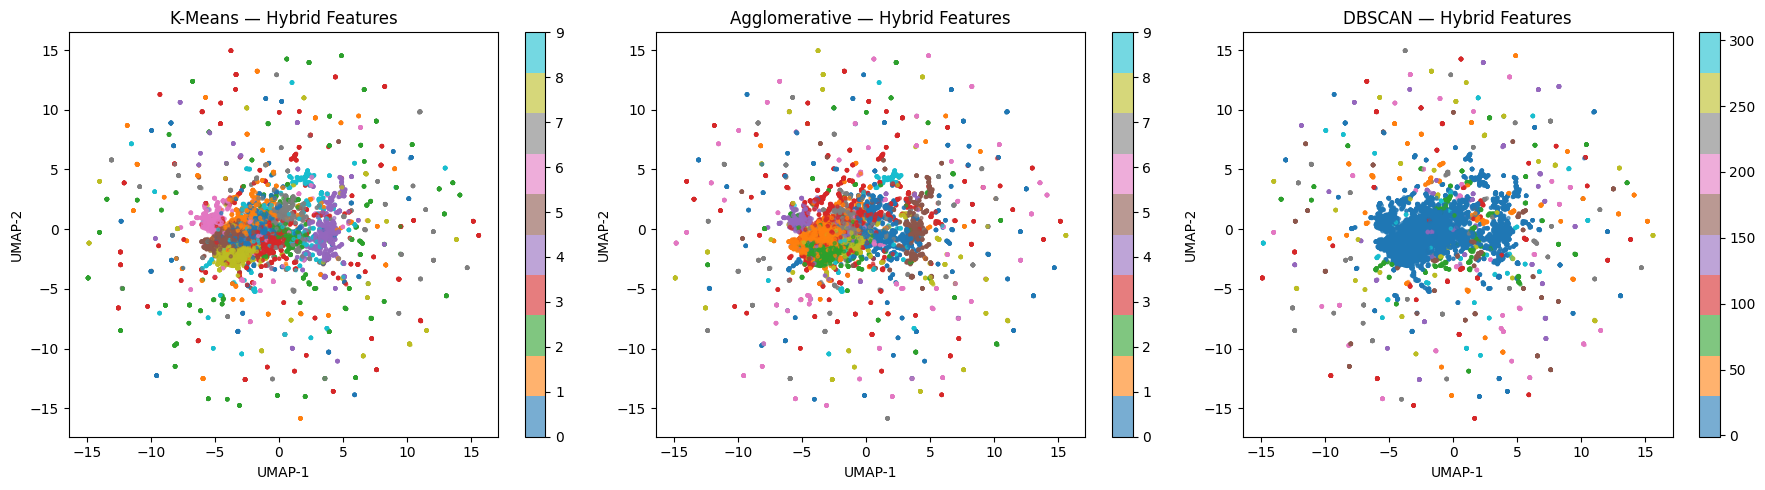

Plot saved.


In [15]:
import matplotlib.pyplot as plt

# 2D UMAP for visualization only
vis_reducer = umap.UMAP(n_components=2, random_state=42)
X_vis = vis_reducer.fit_transform(X_hybrid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, labels, title in zip(
    axes,
    [labels_kmeans_hybrid, labels_agg_hybrid, labels_dbscan_hybrid],
    ["K-Means", "Agglomerative", "DBSCAN"]
):
    scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1],
                         c=labels, cmap="tab10", s=5, alpha=0.6)
    ax.set_title(f"{title} — Hybrid Features")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.savefig("clustering_comparison.png", dpi=150)
plt.show()
print("Plot saved.")